# Attention Mechanisms

## Standard multi-head attention

The driving force behind LLMs and other models that use the transformer architecture is self-attention, a mathematical framework for understanding the relationships between each of the different tokens in a sequence. Self-attention allows an LLM to interpret text data through not only static baseline definitions, but also the context provided by other words and phrases.

In autoregressive LLMs used for text generation, the **attention mechanism helps the model predict the next token in a sequence by determining which previous tokens are most worth “paying attention to” at that moment.** Information from tokens it deems most relevant is given greater attention weights, while information from tokens deemed irrelevant is given attention weights approaching 0.

The multi-head attention mechanism that animates transformer models generates rich contextual information through calculating self-attention many times in parallel by splitting attention layers into multiple attention heads.

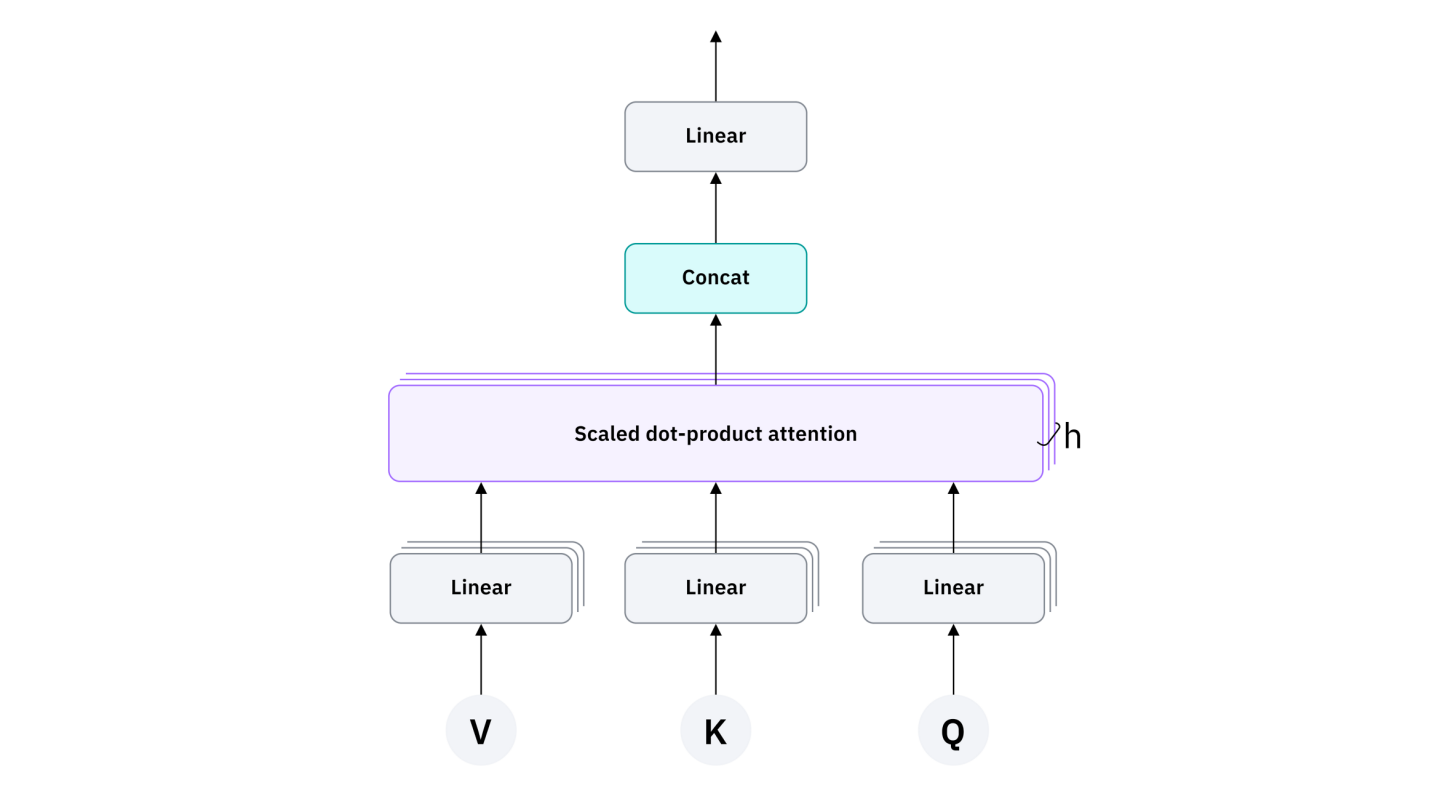


### How standard multi-head attention works
The authors of “Attention is All You Need” articulated its attention mechanism using the terminology of a relational database: queries, keys and values. Relational databases are designed to simplify the storage and retrieval of relevant data: they assign a unique identifier (“key”) to each piece of data, and each key is associated with a corresponding value. The goal of a relational database is to match each query to the appropriate key.

For each token in a sequence, multi-head attention requires the creation of 3 vectors.

- A query vector, Q, representing the information that the token is “seeking.” For instance, the query vector for a noun might represent a search for adjectives that describe it.
- A key vector, K, representing the information that the token contains. Alignment scores, representing the relevance of each token’s key vector to the query vector of each of the other tokens, are used to compute attention weights.
- A value vector, V, representing the contextual information that will be updated by the attention-weighted contributions from the key vectors of other tokens.<br>

The mathematical interactions between these 3 vectors, mediated by the attention mechanism, are how a model adjusts its context-specific understanding of each token.

#### Generating query, key and value vectors
To generate each of these 3 vectors for a given token, the model starts with that token’s original vector embedding: a numerical encoding in which each dimension of the vector corresponds with some abstract element of the token’s semantic meaning. The number of dimensions in these vectors is a predetermined hyperparameter.

The Q, K and V vector for each token are generated by passing the original token embedding through a linear layer that precedes the first attention layer. This linear layer is partitioned into 3 unique matrices of model weights: WQ, WK and WV. The specific weight values therein are learned through self-supervised pretraining on a massive dataset of text examples.

Multiplying the token’s original vector embedding by WQ, WK and WV yields its corresponding query vector, key vector and value vector, respectively. The number of dimensions d each vector contains is determined by the size of each weight matrix. Q and K will have the same number of dimensions, dk.

These 3 vectors are then passed to the attention layer.

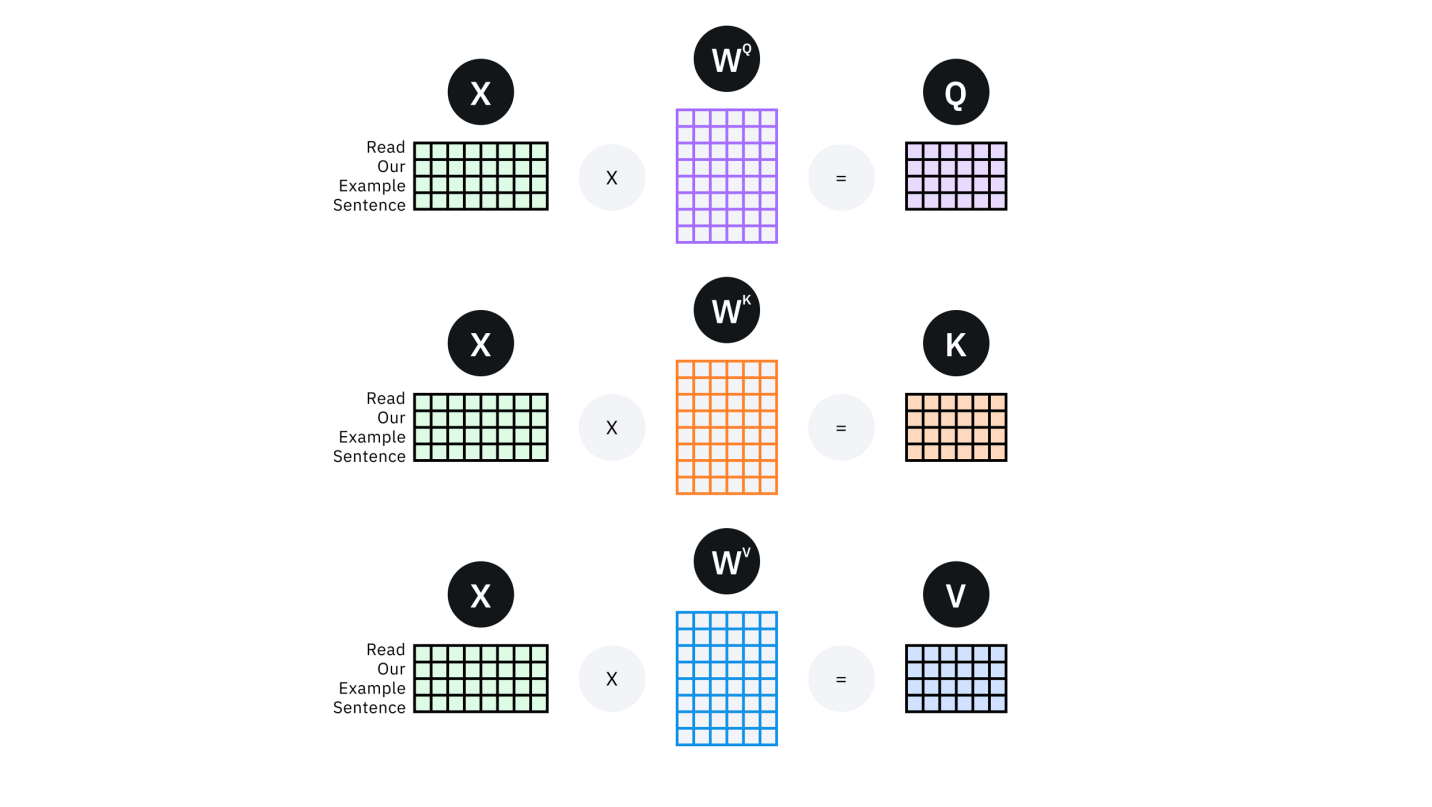

A simplified diagram of the transformer's attention mechanism: the original vector embeddings for the tokens of an input sentence are multiplied by W, K and V weight matrices to yield their respective W, K and V vectors

### Scaled dot product attention and softmax
In the attention layer, the Q, K and V vectors are used to calculate an alignment score between each token at each position in a sequence. Those alignment scores are then normalized into attention weights using a softmax function.

For each token x in a sequence, alignment scores are calculated by computing the dot product of that token’s query vector Qx with the key vector K of each of the other tokens: in other words, by multiplying them together. If a meaningful relationship between 2 tokens is reflected in similarities between their respective vectors, multiplying them together will yield a large value. If the 2 vectors aren’t aligned, multiplying them together will yield a small or negative value. Most transformer models use a variant called scaled dot product attention, in which QK is scaled—that is, multiplied—by $\frac{1}{\sqrt{d}}$
  to improve training stability.

These query-key alignment scores are then typed in to a softmax function. Softmax normalizes all inputs to a value between 0 and 1 such that they all add up to 1. The outputs of the softmax function are the attention weights, each representing the share (out of 1) of token x’s attention to be paid to each of the other tokens. If a token’s attention weight is close to 0, it will be ignored. An attention weight of 1 would mean that a token receives x’s entire attention and all others will be ignored.

Finally, the value vector for each token is multiplied by its attention weight. These attention-weighted contributions from each previous token are averaged together and added to the original vector embedding for token x. With this, token x’s embedding is now updated to reflect the context provided by the other tokens in the sequence that are relevant to it.

The updated vector embedding is then sent to another linear layer, with its own weight matrix WZ, where the context-updated vector is normalized back to a consistent number of dimensions and then sent to the next attention layer. Each progressive attention layer captures greater contextual nuance.

## Multiple attention heads
Using the averages of attention-weighted contributions from other tokens instead of accounting for each piece of attention-weighted context individually is mathematically efficient, but it results in a loss of detail.

To compensate, the transformer networks split the original input token’s embedding into h evenly sized pieces. They likewise split WQ, WK and WV into h subsets called query heads, key head and value heads, respectively. Each query head, key head and value head receives a piece of the original token embedding. The vectors produced by each of these parallel triplets of query heads, key heads and value heads are fed into a corresponding attention head. Eventually, the outputs of these h parallel circuits are concatenated back together to update the full token embedding.

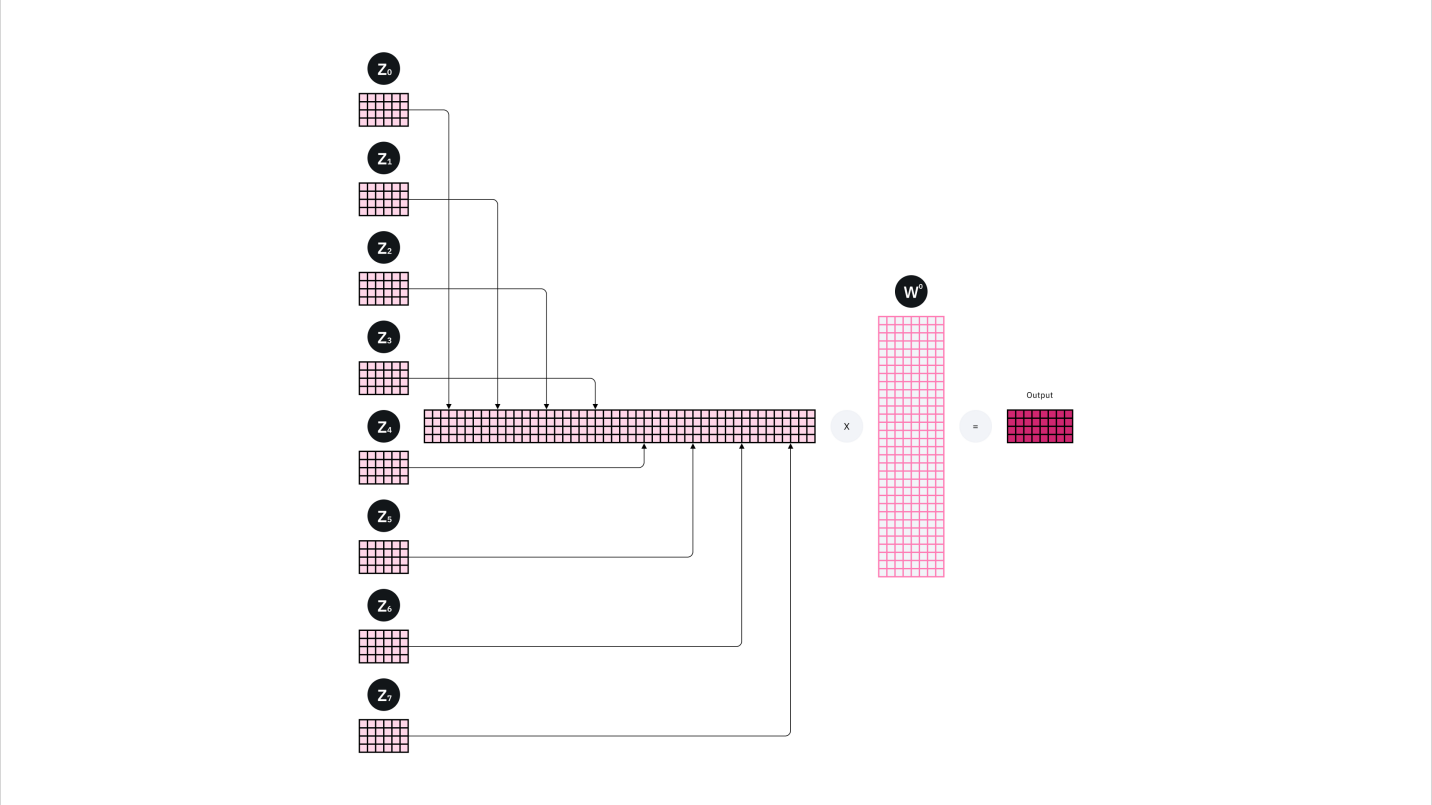
The outputs "Z" of each attention head are concatenated together. In this example, h=8.

In training, each circuit learns distinct weights that capture a separate aspect of semantic meanings. This, in turn, helps the model process the different ways that a word’s implications can be influenced by the context of other words around it.
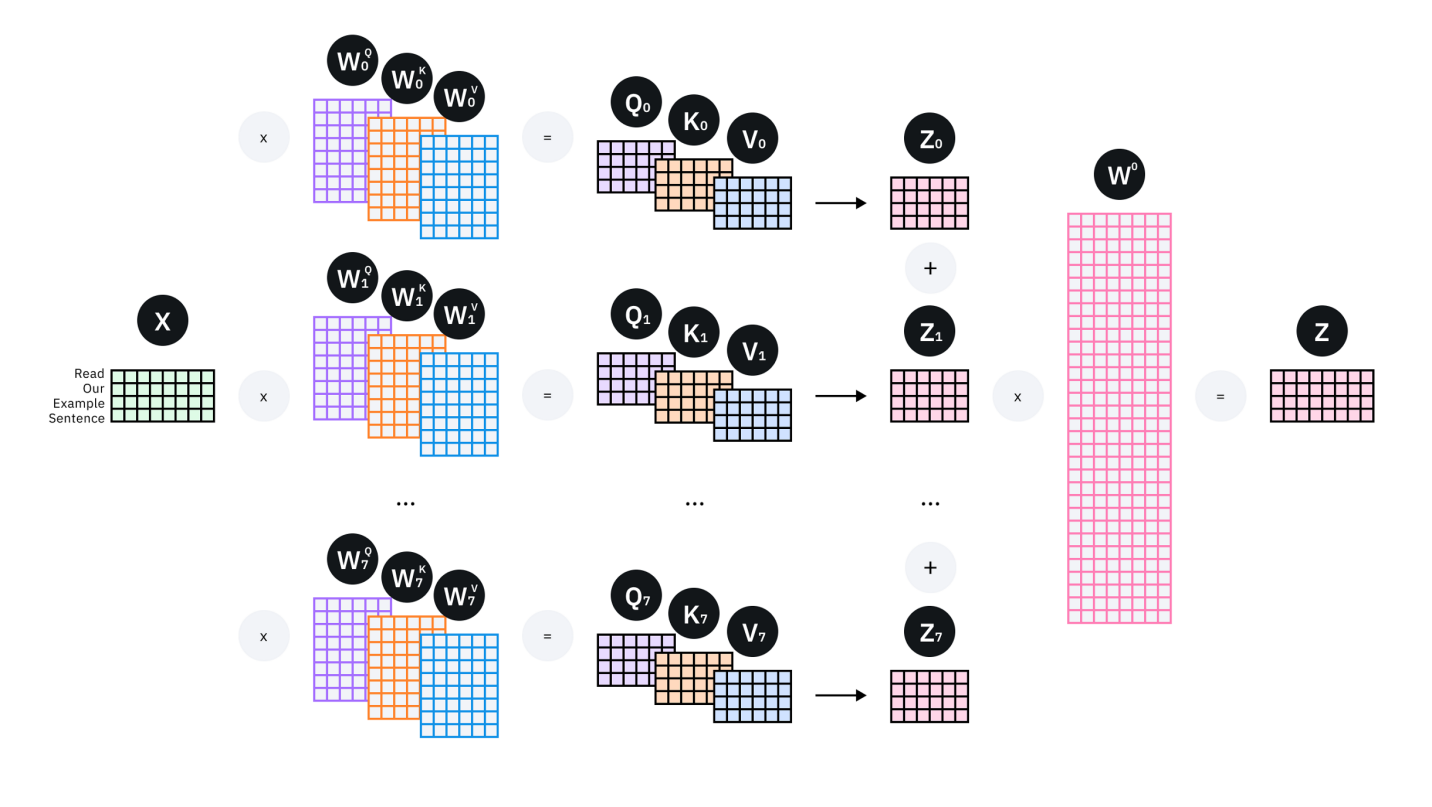

Simplified diagram of all the matrix multiplication in a multi-head attention block (h=8). Derived from Jay Alammar's "The Illustrated Transformer." Note that "+" refers to concatenation, rather than addition.

### Disadvantages of standard multi-head attention
The downside of standard multi-head attention is the lack of any optimization. MHA was the first algorithm of its kind and represents the most complex execution of its general mechanism for attention computation.

Most of MHA’s inefficiency stems from the abundance of calculations and model parameters. In standard MHA, each query head, key head and value head in each attention block has its own matrix of weights. So, for instance, **a model with 8 attention heads in each attention layer—far fewer than most modern LLMs—would require 24 unique weight matrices for the layer's Q, K and V heads alone. This entails a huge number of intermediate calculations at each layer.**

**One consequence of this configuration is that it’s computationally expensive. Compute requirements for MHA scale quadratically with respect to sequence length:** doubling the number of tokens in an input sequence requires quadruple the complexity. This puts hard practical limits on the size of context windows.

MHA also puts a major strain on system memory. GPUs don’t have much on-board memory to store the outputs of the massive quantity of intermediate calculations that must be recalled at each subsequent processing step. These intermediate results are instead stored in high-bandwidth memory (HBM), which isn’t located on the GPU chip itself. This entails a small amount of latency each time keys and values must be read from memory. As transformer models began to scale to many billions of parameters, the time and compute required to train and run inference became a bottleneck on model performance.

Further progress required methods to reduce the number of computational steps without reducing the capacity of transformers to learn and reproduce intricately complex linguistic patterns. It was in this context that MQA, and subsequently GQA, were introduced.

## Key-Value Cache
As understood in above, During inference,to generate each next token in the sequence model need to multiply our query matrix, with same Key and Value matrixes for each token. We need to repeat this process for each newly generated token, which involves a lot of repeated calculation. This leads to a technique called Key-Value cache.

As suggested by its name, Key-Value cache is a technique designed to speedup the autoregressive process by caching and reusing the previous keys and values, rather than re-computing them at each decoding step.

Note that KV cache is typically used only during the inference stage, since in training we still need to process the entire input sequence in parallel.

KV cache is commonly implemented as a rolling buffer. At each decoding step, only the new query Q is computed, while the K and V stored in the cache will be reused, so that the attention will be computed using the new Q and reused K, V. Meanwhile, the new token’s K and V will also be appended to the cache for later use.

However, the speedup achieved by KV cache comes at a cost of memory, since KV cache often scales with batch size × sequence length × hidden size × number of heads, leading to a memory bottleneck when we have larger batch size or longer sequences.

In [ ]:
# Pseudocode for KV Caching in PyTorch
class KVCache:
    def __init__(self):
        self.cache = {"key": None, "value": None}

    def update(self, key, value):
        if self.cache["key"] is None:
            self.cache["key"] = key
            self.cache["value"] = value
        else:
            self.cache["key"] = torch.cat([self.cache["key"], key], dim=1)
            self.cache["value"] = torch.cat([self.cache["value"], value], dim=1)

    def get_cache(self):
        return self.cache

## Multi-query attention (MQA)
### How multi-query attention (MQA) works
Multi-query attention (MQA) is a more computationally efficient attention mechanism that simplifies multi-head attention to reduce memory usage and intermediate calculations. Instead of training a unique key head and value head for each attention head, MQA uses a single key head and single value head at each layer. Therefore, key vectors and value vectors are calculated only once; this single set of key and value vectors is then shared across all h attention heads.

This simplification greatly reduces the number of linear projections that the model must calculate and store in high-bandwidth memory. According to the 2019 paper that introduced MQA, MQA allows a 10–100 times smaller key-value pair storage (or KV cache) and 12 times faster decoder inference. MQA’s reduced memory usage also significantly speeds up training by enabling a larger batch size.

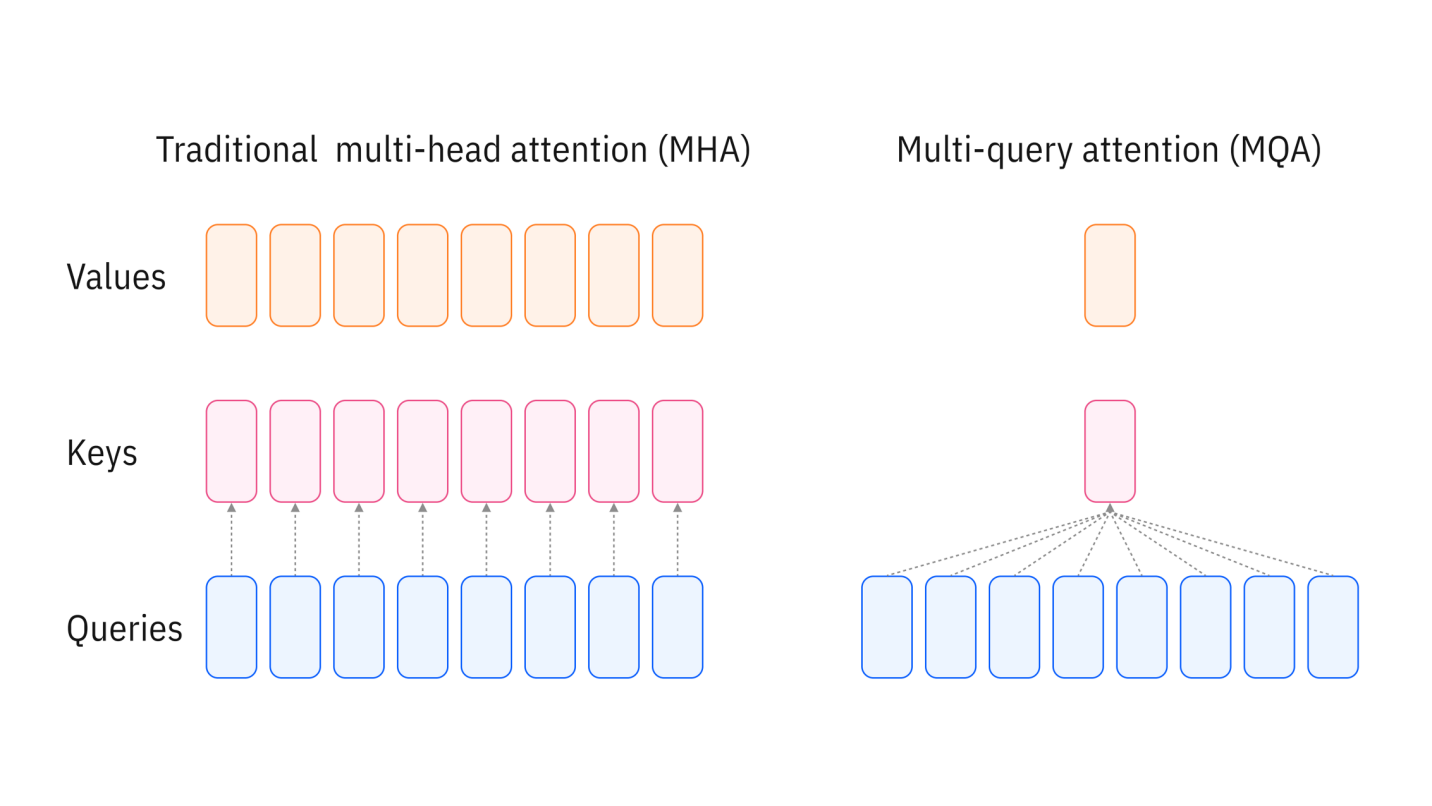

### Disadvantages of multi-query attention (MQA)
Despite its benefits, MQA comes with several unavoidable downsides.

**Performance degradation**: Unsurprisingly, reducing the number of unique, trainable model parameters reduces the model’s capacity for knowledge and nuance. MQA entails a meaningful drop in accuracy compared to standard MHA, making it unsuitable for certain situations and use cases.

**Must be trained from scratch**: A model trained with standard MHA cannot be simply adapted to MQA, but must instead be trained with MQA from scratch. This means MQA cannot be used to optimize existing models and entails a considerable opportunity cost when experimenting with MQA for new models.

**Redundancies in tensor parallelism**: One of the main benefits of training transformer models on GPUs is the ability to perform multiple complex tensor operations in parallel. K and V values must be present on each node of the GPU cluster performing these operations, which means that in practice they must be replicated for each node. This is not an optimal use of compute resources despite still being more efficient than standard MHA.

## Grouped query attention
### How grouped query attention (GQA) works
Grouped query attention is a more general, flexible formulation of multi-query attention that partitions query heads into multiple groups that each share a set of keys and values, rather than sharing one set of keys and values across all query heads.

Following the publication of “GQA: Training Generalized Multi-Query Transformer Models from Multi-Head Checkpoints” in May 2023, many LLMs quickly adopted GQA. For instance, Meta first adopted GQA for its Llama 2 models in July 2023 and retained GQA in the Llama 3 models released in 2024. Mistral AI used GQA in the Mistral 7B model that it released in September 2023. Likewise, IBM’s Granite 3.0 models employ GQA for fast inference.

Grouped query attention versus multi-query attention versus multi-head attention
In theory, GQA can be thought of as a generalization of the spectrum between standard MHA and full MQA. GQA with the same number of key-value head groups as attention heads is the equivalent of standard MHA; GQA with 1 head group is the equivalent of MQA.

In practice, GQA almost always implies some intermediate approach, in which the number of groups is itself an important hyperparameter.

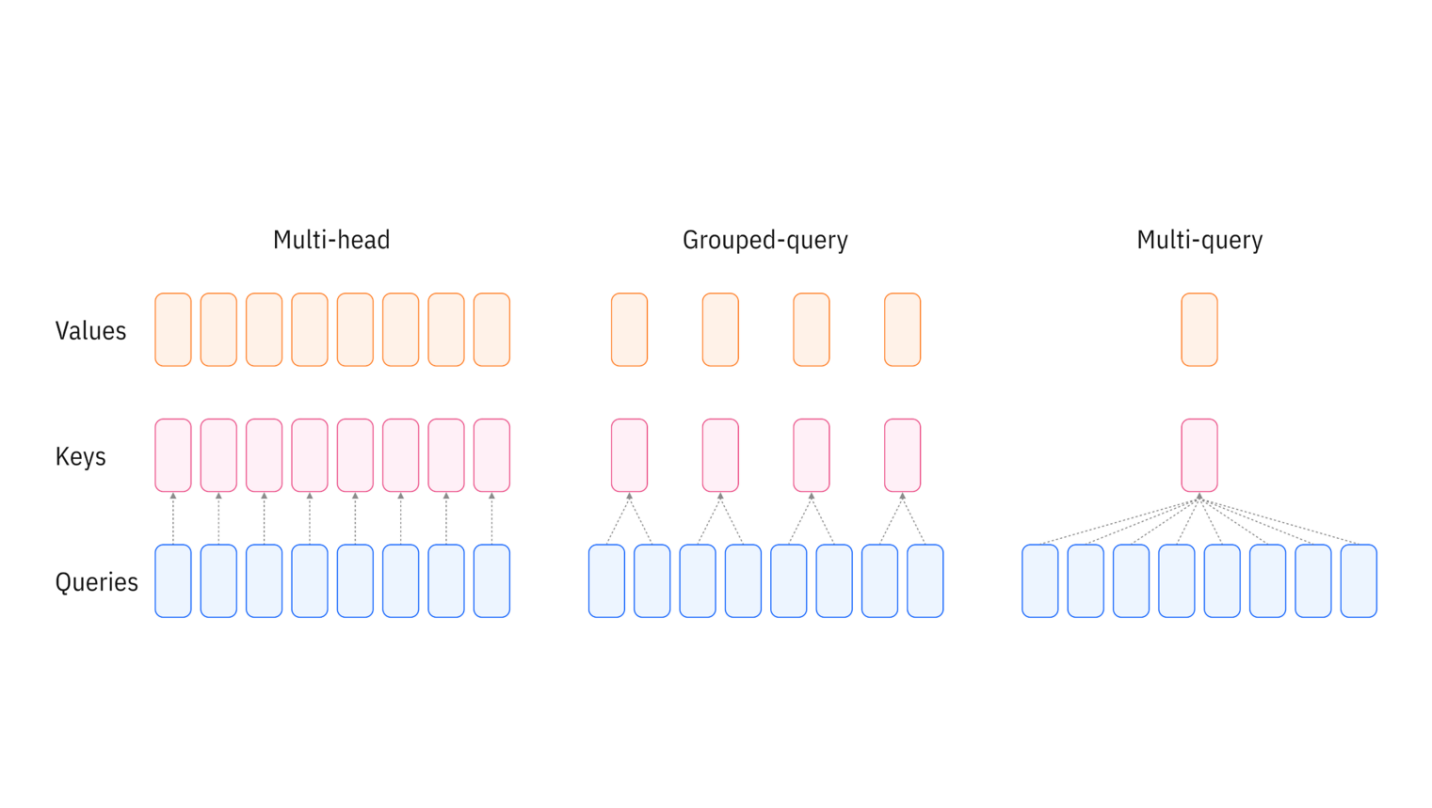

### Benefits of grouped query attention
Grouped query attention offers several advantages that have led to its relatively widespread adoption for leading LLMs.

- **Efficient GPU usage**: GQA’s distribution of key-value pairs takes advantage of tensor parallelism, reducing the amount of compute that’s “wasted” by replicating redundant values.

- **Effective compromise**: GQA offers an ideal tradeoff between decoder inference speed and performance accuracy, in that it's nearly as accurate as MHA while being nearly as fast as MQA.

- **Reduced memory bandwidth overhead**: Like MQA, GQA significantly reduces the number of intermediate calculations that must be computed, stored and retrieved at inference time.

- **Flexible training**: Unlike MQA, group query attention doesn’t require models to be trained from scratch using the approach. Models pretrained using standard MHA can be adapted to use GQA through a fine-tuning process called “uptraining.”

## Multi-Head Latent Attention
### What is MLA (Multi-Head Latent Attention)?
MLA is a new attention mechanism designed to be:

More efficient in memory use than traditional multi-head attention (MHA) or group-query attention (GQA).
Fully compatible with long context inference and fast decoding—especially within the DeepSeek ecosystem.
It compresses the key-value (KV) cache used in autoregressive transformers—dramatically reducing memory usage and improving speed—without losing performance.

##### Core Idea
In traditional attention (MHA/GQA):

Each attention head stores its own key and value vectors in the KV cache.
This leads to huge memory requirements during inference, especially with long sequences.

In MLA:

The KV cache is projected into a low-rank latent space via learnable matrices.
This means you don't need to store per-head keys/values anymore.
Instead, all heads share a single compact latent KV space (e.g., 8-16 dimensions instead of hundreds).

### How It Works (Architecturally)
Let’s break it down step by step:

1. **Latent Key/Value Projections**<br>
Let k, v be the key and value representations at each time step.

MLA projects them into a low-rank latent space using learned matrices:

k_latent = k × P_k

v_latent = v × P_v

Where P_k and P_v are projection matrices.

2. **Attention Uses Latent KV**<br>
During attention computation:

Instead of using k and v directly, each head uses the shared latent k_latent, v_latent.

The query q interacts with these to compute attention scores.

3. **Absorb Operation**<br>
When new tokens are added, instead of growing the latent KV cache linearly, MLA uses an "Absorb" operation to compress new keys/values into the same fixed-size latent cache.

This prevents KV-cache blowup, even with long contexts.

### Why It Matters
**Traditional Attention → High Memory Use**
Each new token increases the KV cache size.

Especially problematic for large context lengths (e.g. 8K, 32K tokens).

**MLA → Constant Cache Size**
Only a fixed-size latent cache needs to be stored.

Makes MLA extremely scalable and fast for long-context inference.


### Analogy
Imagine each attention head is a reporter at a press conference (token sequence):

In MHA, each reporter records everything themselves—lots of data, lots of duplication.

In GQA, reporters share the same camera feed—but only a few cameras exist.

In MLA, there’s one super-smart camera system that records a summary of everything, and each reporter accesses just what they need from it.

### In the TransMLA paper:

They show that MLA can match or beat GQA performance on benchmarks after just 6 billion tokens of fine-tuning.

KV cache memory is reduced by ~93% (e.g., from 1024 MB to 72 MB on LLaMA-2/7B).

Also with the help of TransMLA, any model trained using GQA can be transfered into MLA, but after decoupling of RoPE (Rotary Positional Encoding).

**Converted GQA → MLA**: TransMLA provides a post-training framework that transforms any GQA‑based model (e.g., LLaMA‑2/3, Qwen, Mixtral) into an MLA‑based one without needing to train from scratch.

Key techniques:

**Theoretical mapping**: Shows GQA is strictly a subset of MLA in expressive power (i.e., MLA ≥ GQA at same KV-cache size).

**RoPE handling with PCA (RoRoPE)**: Rotary Position Embedding (RoPE) complicates low-rank KV transformations. TransMLA applies PCA to concentrate positional embeddings and then rotates and factors KV layers such that RoPE can be absorbed cleanly.

**Post‑training fine‑tuning**: Uses only ~6 billion tokens to restore or match original model performance, rather than re-training fully

### Theoretical Insight
The paper proves:

GQA is a special case of MLA
That means: every GQA model can be represented within the MLA framework.

This makes MLA strictly more expressive than GQA.

### Summary
Multi-Head Latent Attention (MLA) is a next-gen attention mechanism that:

- Projects keys/values into a shared, low-rank latent space.
- Uses compression to keep cache size constant.
- Achieves massive memory savings.
- Enables faster inference, especially for long sequences.
- Is fully compatible with DeepSeek’s advanced runtimes.

# Flash Attention

## Problem
Scaling the transformer architecture is heavily bottlenecked by the self-attention mechanism, which has quadratic time and memory complexity ($O(N^2)$ where N is the sequence length). Recent developments in accelerator hardware mainly focus on enhancing compute capacities and not memory and transferring data between hardware. This results in attention operation having a memory bottleneck.

## Analogy
Flash Attention is an attention algorithm used to reduce this problem and scale transformer-based models more efficiently, enabling faster training and inference.<br>

Standard attention mechanism uses High Bandwidth Memory (HBM) to store, read and write keys, queries and values.<br>
HBM is large in memory, but slow in processing, meanwhile SRAM is smaller in memory, but faster in operations. In the standard attention implementation, the cost of loading and writing keys, queries, and values from HBM is high. It loads keys, queries, and values from HBM to GPU on-chip SRAM, performs a single step of the attention mechanism, writes it back to HBM, and repeats this for every single attention step.<br>
Instead, Flash Attention loads keys, queries, and values once, fuses the operations of the attention mechanism, and writes them back.

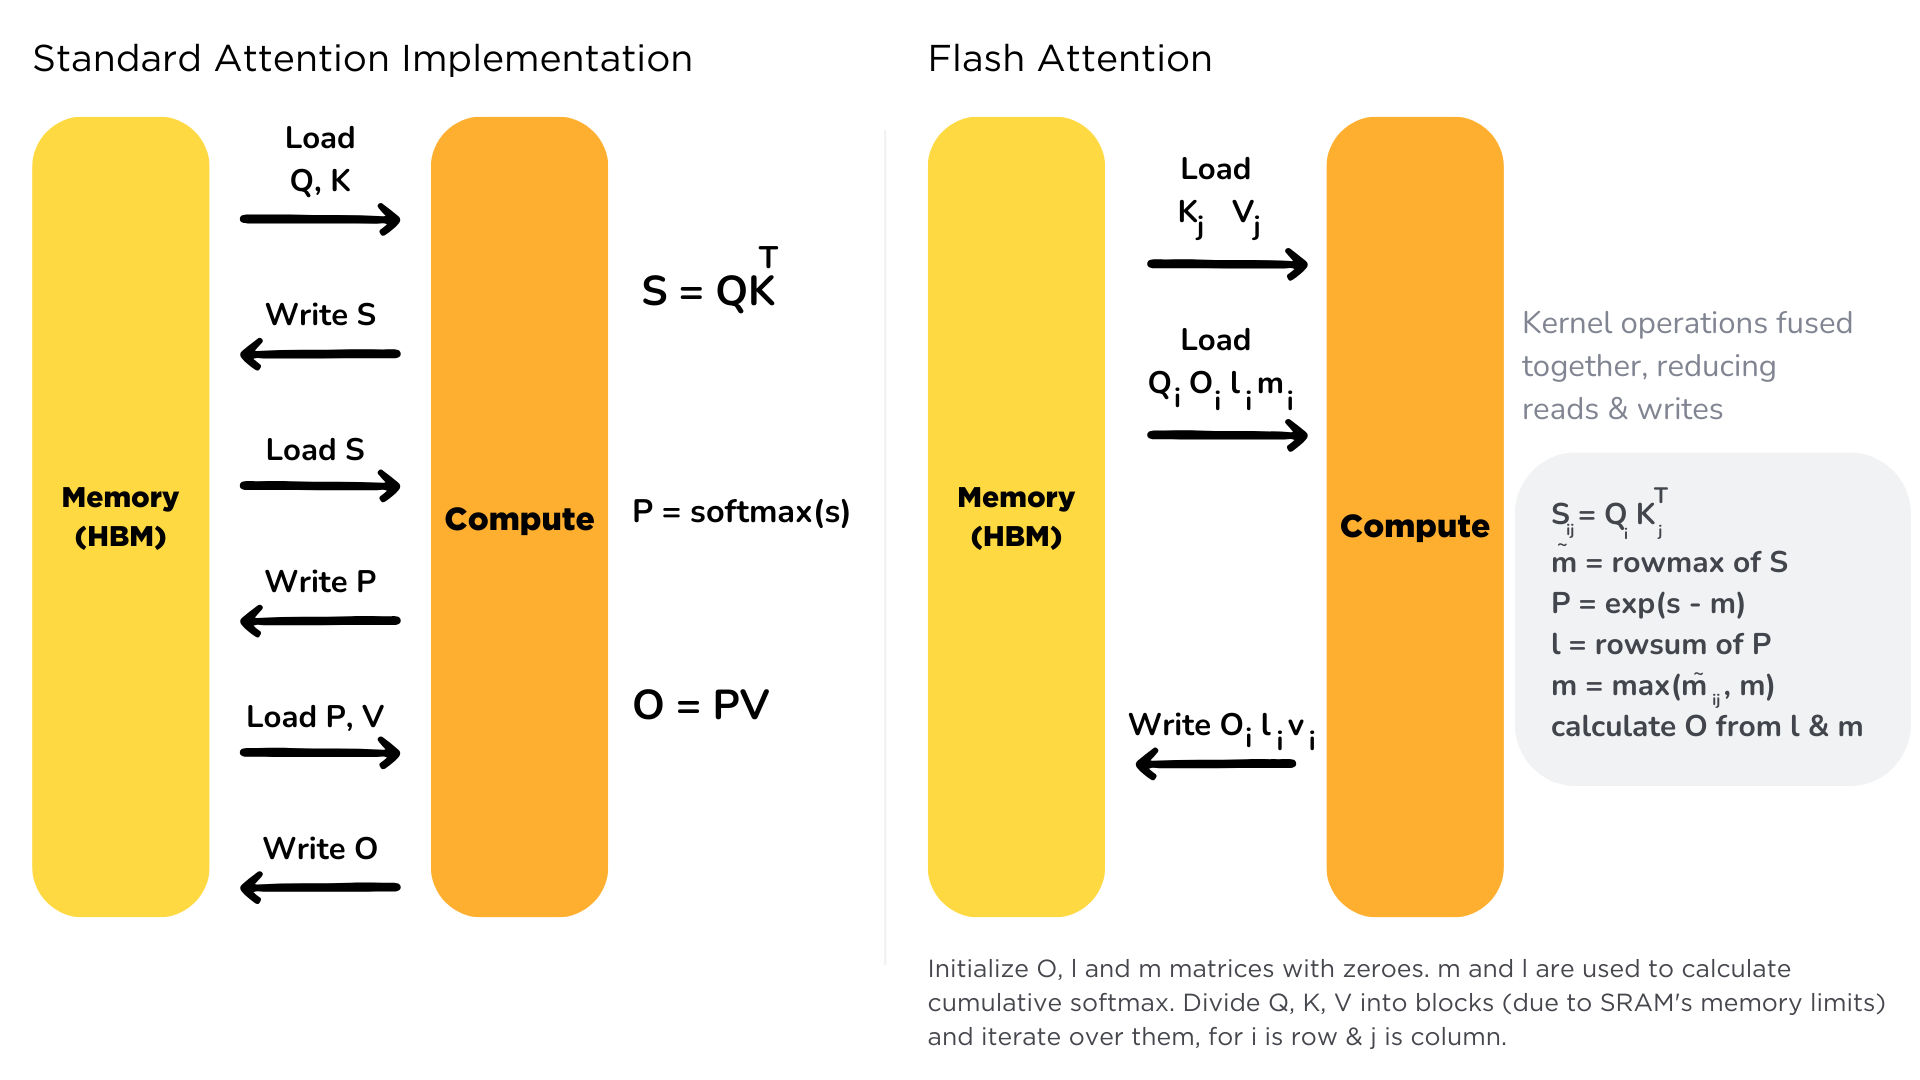

## ⚡ How FlashAttention Works

Flash Attention solves these problems by being "IO-aware" - it's designed around the memory hierarchy of modern GPUs. The key insight is that you don't need to store the entire attention matrix in memory.

The algorithm works by:
- **Tiling + blocking:**  Processes sequences in smaller chunks (tiles), fitting into GPU’s fast on-chip memory (SRAM/shared memory)..
- **Fused Kernels:** Combines softmax + attention computation in a single GPU kernel to avoid slow memory access.
- **Online Softmax:** Numerically stable way to compute softmax incrementally, without storing all attention scores.


## 🧮 High-Level Algorithm

```text
for each query block:
    for each key-value block:
        1. Load Q, K, V tiles into GPU SRAM
        2. Compute attention scores = Q × Kᵀ
        3. Apply online softmax (numerically stable)
        4. Compute weighted sum: softmax(QKᵀ) × V
        5. Accumulate results in output buffer
```

## 📊 Summary Table

| Feature                      | MHA (Multi-Head)      | MLA (Multi-Query)       | GQA (Grouped Query)       | FlashAttention                |
|-----------------------------|------------------------|--------------------------|----------------------------|-------------------------------|
| **Q (Queries)**             | 🔁 Per head            | 🔁 Per head              | 🔁 Per head                | 🔁 Per head                   |
| **K/V (Keys/Values)**       | 🔁 Per head            | ✅ Shared across heads   | ⚖️ Shared per group         | Same as base config (e.g., MHA, GQA, etc.) |
| **KV Cache Size**           | 🔺 Very high           | ✅ ~1/N smaller          | ⚖️ Medium (e.g., N/4)       | ✅ Reduces runtime memory     |
| **Memory Usage (runtime)**  | 🔺 High                | ✅ Very low              | ⚖️ Lower than MHA           | ✅ Lowest (GPU optimized)     |
| **Inference Speed**         | 🔺 Slowest             | ✅ Fastest               | ⚖️ Faster than MHA          | ✅ Very Fast (2–4× MHA)       |
| **Training Speed**          | 🔺 Baseline            | ✅ Fast                  | ✅ Fast                     | ✅ Fastest                    |
| **Accuracy (vs MHA)**       | ✅ Best                | ⚠️ Slightly lower        | ⚖️ Close to MHA             | ✅ Same as base attention     |
| **GPU Optimization**        | ❌ None                | ❌ None                  | ❌ None                     | ✅ Fused, tiled GPU kernels   |
| **DeepSeek / GPT-4/Gemma**  | ❌ Not used            | ✅ Used in LLaMA-2, Palm | ✅ Used in LLaMA/GPT-4      | ✅ Used (FlashAttention-2)    |

### 🔍 Summary

- **MHA**: High memory, high expressiveness, but slow.
- **GQA**: Lower cache cost, but reduced representational power.
- **MLA**: Compresses memory like GQA while retaining (or improving on) MHA’s expressiveness, plus it supports features like DeepSeek'
- **FlashAttention**: Uses IOAware algorithm by reducing number of I/O operation between compute and Memory.


# ⚡ FlashAttention 2: Next-Gen Efficient Attention

## 🚀 What is FlashAttention 2?

**FlashAttention 2** is an improved and faster version of FlashAttention (v1), designed for efficient and scalable Transformer attention. It provides **exact** attention computation (not approximate), with support for **variable sequence lengths**, **head parallelism**, **RoPE**, and **lower precision formats (e.g., FP8, INT8)**.

> 📌 Paper: [FlashAttention-2 (arXiv:2307.08691)](https://arxiv.org/abs/2307.08691)  
> 📦 GitHub: [HazyResearch/flash-attention](https://github.com/HazyResearch/flash-attention)


## 🧠 Why FlashAttention 2?

FlashAttention 1 was already fast, but had some limitations:
- ❌ No support for padded sequences
- ❌ No head parallelism → slow inference
- ❌ Hard to integrate RoPE (rotary embeddings)
- ❌ Limited support for new hardware like Hopper GPUs


## ⚙️ Key Features of FlashAttention 2

| Feature                     | Description                                                                 |
|----------------------------|-----------------------------------------------------------------------------|
| ✅ **Head Parallelism**     | Processes multiple attention heads in parallel → faster inference            |
| ✅ **Supports Padding**     | Accepts padded input → easier batching and real-world use                   |
| ✅ **Supports RoPE**        | Built-in support for rotary positional embeddings                           |
| ✅ **Supports GQA & MQA**   | Works with Grouped Query and Multi-Query Attention                          |
| ✅ **Low Precision**        | Supports FP16, BF16, INT8, and FP8 for faster and smaller models            |
| ✅ **Faster Backward Pass** | Efficient gradients during training                                          |
| ✅ **Large Sequence Lengths** | Handles 64k+ tokens efficiently (great for long-context models)            |


## 🧮 How It Works (Simplified)

FlashAttention 2 improves over v1 by:
- Rewriting GPU kernels to support **multi-head parallelization**
- Using better **tiling and shared memory layouts**
- Reducing memory traffic (reads/writes) further
- Supporting **variable-length** input using **offsets and masks**

### High-Level Pseudocode:

```text
for each block of queries:
    parallel across heads:
        for each block of keys:
            1. Load Q, K, V tiles into fast GPU memory
            2. Compute QKᵀ (scaled dot-product)
            3. Apply softmax using online algorithm (stable & fused)
            4. Multiply by V and accumulate output
```

## 🧬 Key Differences

| Feature                      | FlashAttention v1                         | FlashAttention v2                              |
|-----------------------------|-------------------------------------------|------------------------------------------------|
| **Release Year**            | 2022                                      | 2023                                           |
| **Input Type**              | FP16 / BF16                               | ✅ Supports FP16, BF16, INT8, FP8               |
| **Causal Masking**          | ✅ Supported                              | ✅ Supported (more efficiently)                |
| **Padding Support**         | ❌ Sequences must be unpadded              | ✅ Supports padded + variable length sequences |
| **Head Parallelism**        | ❌ Sequential across heads                 | ✅ Parallel across heads (faster inference)     |
| **Backward Pass**           | ✅ Supported                               | ✅ Faster and more memory-efficient            |
| **Multi-query / Grouped Q** | ❌ Not optimized                           | ✅ Efficient support for MQA / GQA             |
| **FlashAttention + RoPE**   | Manual                                    | ✅ Integrated                                   |
| **Hardware Support**        | NVIDIA Ampere+                            | ✅ Optimized for Hopper + future GPUs          |
| **Speed**                   | 2–4× faster than standard attention        | ✅ 2× faster than v1 in some cases             |
| **Memory Access Pattern**   | SRAM-based tiling                         | ✅ Better shared-memory scheduling             |

``` code
from flash_attn import flash_attn_func
# Run FlashAttention 2
out = flash_attn_func(q, k, v, dropout_p=0.0, causal=True)
```